###  Analisis exploratorio de datos
dataset: Chicago_crimes_2021_2017

Librerias usada:

In [ ]:
%pip install hdbscan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering as AC
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap

from sklearn.cluster import KMeans
import hdbscan

%matplotlib inline

Eliminamos atributos irrelevantes para el analisis del dataset

## Clusters

In [ ]:

# Read the CSV file back into a DataFrame
crimes_new1 = pd.read_csv('crimes_new1.csv')

# Print some info to verify
print(crimes_new1.info())
print(crimes_new1.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28367 entries, 0 to 28366
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    28367 non-null  int64  
 1   Date                  28367 non-null  object 
 2   Block                 28367 non-null  object 
 3   Primary Type          28367 non-null  object 
 4   Description           28367 non-null  object 
 5   Location Description  28367 non-null  object 
 6   Arrest                28367 non-null  bool   
 7   Domestic              28367 non-null  bool   
 8   District              28367 non-null  float64
 9   X Coordinate          28367 non-null  float64
 10  Y Coordinate          28367 non-null  float64
 11  Latitude              28367 non-null  float64
 12  Longitude             28367 non-null  float64
dtypes: bool(2), float64(5), int64(1), object(5)
memory usage: 2.4+ MB
None
         ID                 Date                  

In [ ]:
# Load the data back from the CSV file
df_X_loaded = pd.read_csv('X_data.csv')

# Convert the loaded DataFrame back to a NumPy array
X = df_X_loaded.values

# Now X_loaded has the same structure as X.
# You can use X_loaded in subsequent steps in place of X

In [ ]:
X.shape

(28367, 41)

### HDBSCAN

In [ ]:
# Verificar que X no esté vacío
if X.size == 0:
    raise ValueError("La matriz X está vacía. Por favor, verifica los datos de entrada.")

In [ ]:
# Inicializar listas para almacenar métricas
'''min_cluster_sizes = [250,300,350,400,450]  # Tamaños mínimos de clúster a probar
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
num_clusters_detected = []

print("Calculando métricas de calidad para diferentes valores de min_cluster_size en HDBSCAN...\n")
for i, min_cluster_size in enumerate(min_cluster_sizes):
    clustering = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    clusters = clustering.fit_predict(X)

    # Validar si hay al menos 2 clusters válidos
    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
    num_clusters_detected.append(n_clusters)

    if n_clusters > 1:
        silhouette = silhouette_score(X, clusters)
        davies_bouldin = davies_bouldin_score(X, clusters)
        calinski_harabasz = calinski_harabasz_score(X, clusters)
    else:
        silhouette = davies_bouldin = calinski_harabasz = np.nan

    # Almacenar los resultados
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)

    # Mostrar resultados intermedios
    print(f"{i+1}. Valor de min_cluster_size: {min_cluster_size}")
    print(f"  Número de clústeres detectados: {n_clusters}")
    print(f"  Silhouette Score: {silhouette:.3f}" if not np.isnan(silhouette) else "  Silhouette Score: N/A")
    print(f"  Davies-Bouldin Score: {davies_bouldin:.3f}" if not np.isnan(davies_bouldin) else "  Davies-Bouldin Score: N/A")
    print(f"  Calinski-Harabasz Score: {calinski_harabasz:.3f}" if not np.isnan(calinski_harabasz) else "  Calinski-Harabasz Score: N/A")
    print()

# Gráfica de los scores en subplots
plt.figure(figsize=(15, 12))

# Silhouette Score
plt.subplot(4, 1, 1)
plt.plot(min_cluster_sizes, silhouette_scores, marker='o', color="blue", label="Silhouette Score")
plt.title('Silhouette Score por Valor de min_cluster_size')
plt.xlabel('min_cluster_size')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.legend()

# Davies-Bouldin Score
plt.subplot(4, 1, 2)
plt.plot(min_cluster_sizes, davies_bouldin_scores, marker='o', color="orange", label="Davies-Bouldin Score")
plt.title('Davies-Bouldin Score por Valor de min_cluster_size')
plt.xlabel('min_cluster_size')
plt.ylabel('Davies-Bouldin Score (menor es mejor)')
plt.grid(True)
plt.legend()

# Calinski-Harabasz Score
plt.subplot(4, 1, 3)
plt.plot(min_cluster_sizes, calinski_harabasz_scores, marker='o', color="green", label="Calinski-Harabasz Score")
plt.title('Calinski-Harabasz Score por Valor de min_cluster_size')
plt.xlabel('min_cluster_size')
plt.ylabel('Calinski-Harabasz Score')
plt.grid(True)
plt.legend()

# Número de clústeres detectados
plt.subplot(4, 1, 4)
plt.plot(min_cluster_sizes, num_clusters_detected, marker='o', color="purple", label="Número de Clústeres")
plt.title('Número de Clústeres Detectados por Valor de min_cluster_size')
plt.xlabel('min_cluster_size')
plt.ylabel('Número de Clústeres')
plt.grid(True)
plt.legend()

# Ajuste del espacio entre subplots
plt.tight_layout()
plt.show()
'''

'min_cluster_sizes = [250,300,350,400,450]  # Tamaños mínimos de clúster a probar\nsilhouette_scores = []\ndavies_bouldin_scores = []\ncalinski_harabasz_scores = []\nnum_clusters_detected = []\n\nprint("Calculando métricas de calidad para diferentes valores de min_cluster_size en HDBSCAN...\n")\nfor i, min_cluster_size in enumerate(min_cluster_sizes):\n    clustering = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)\n    clusters = clustering.fit_predict(X)\n\n    # Validar si hay al menos 2 clusters válidos\n    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)\n    num_clusters_detected.append(n_clusters)\n\n    if n_clusters > 1:\n        silhouette = silhouette_score(X, clusters)\n        davies_bouldin = davies_bouldin_score(X, clusters)\n        calinski_harabasz = calinski_harabasz_score(X, clusters)\n    else:\n        silhouette = davies_bouldin = calinski_harabasz = np.nan\n\n    # Almacenar los resultados\n    silhouette_scores.append(silhouette)\n    davies_

In [ ]:
# Crear un modelo HDBSCAN con el mejor valor de min_cluster_size
best_min_cluster_size = 350
clustering = hdbscan.HDBSCAN(min_cluster_size=best_min_cluster_size)
clusters = clustering.fit_predict(X)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Gráfica de los clusters
# Convertir a 2 dimensiones para la visualización
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
unique_clusters = set(clusters)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for cluster, color in zip(unique_clusters, colors):
    if cluster == -1:
        label = 'Ruido'
        alpha = 0.3
    else:
        label = f'Cluster {cluster}'
        alpha = 0.8
    plt.scatter(X_2d[clusters == cluster, 0], X_2d[clusters == cluster, 1],
                s=50, c=[color], label=label, alpha=alpha)

plt.title(f'Visualización de Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.manifold import TSNE, Isomap

In [ ]:
# Convertir a 2 dimensiones para la visualización con t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)
unique_clusters = set(clusters)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
plt.figure(figsize=(10, 8))
for cluster, color in zip(unique_clusters, colors):
    if cluster == -1:
        label = 'Ruido'
        alpha = 0.3
    else:
        label = f'Cluster {cluster}'
        alpha = 0.8
    plt.scatter(X_tsne[clusters == cluster, 0], X_tsne[clusters == cluster, 1],
                s=50, c=[color], label=label, alpha=alpha)

plt.title(f'Visualización de Clusters con t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
columnas_binarias = crimes_new1.select_dtypes(include=['bool']).columns
#crimes_new[columnas_binarias] = crimes[columnas_binarias].astype(int)

#Se toma el resultado hscan (metodo agglo_2 sobre el dataset normalizado y aplicado isomap) por tener el mejor silouethe score
crimes_new1['cluster'] = clusters


resultados = crimes_new1.groupby('cluster').describe()
resultados.to_csv('ResultadosHDBSCAN.csv')
crimes_new1.head()

In [ ]:
results = pd.DataFrame({
    'Cluster': clusters
})

# Si tienes columnas originales que deseas incluir en los resultados
if isinstance(crimes_new1, pd.DataFrame):
    results = pd.concat([crimes_new1.reset_index(drop=True), results], axis=1)

# Guardar los resultados en un archivo CSV
output_file = 'resultados_hdbscan.csv'
results.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Resultados guardados en el archivo: {output_file}")

In [ ]:
#Cuenta las instancias de cada cluster
cluster_summary = crimes_new1['cluster'].value_counts()
print(cluster_summary)

In [ ]:
top_cluster = crimes_new1[crimes_new1['cluster'] == cluster_summary.idxmax()]
print(top_cluster.describe())

In [ ]:
cluster_stats = crimes_new1.groupby('cluster')[['Primary Type', 'Location Description']].value_counts()
print(cluster_stats)

In [ ]:
results = pd.read_csv('resultados_hdbscan.csv')

crime_counts_by_cluster = results.groupby('cluster')['Primary Type'].value_counts().unstack(fill_value=0)

# Create the bar plot
crime_counts_by_cluster.plot(kind='bar', figsize=(15, 6))
plt.title('Número de crímenes por tipo en cada cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Crimen')
plt.tight_layout()
plt.show()

In [ ]:
# Convert the 'Date' column to datetime objects
results['Date'] = pd.to_datetime(results['Date'])

# Extract month and year
results['Month'] = results['Date'].dt.month
results['Year'] = results['Date'].dt.year

# Group by cluster, month, and crime type, then count occurrences
crime_frequencies = results.groupby(['Cluster', 'Month', 'Primary Type'])['ID'].count().reset_index()

# Display the result
print(crime_frequencies)


#Optional: Pivot table for better visualization
crime_frequencies_pivot = crime_frequencies.pivot_table(index=['Cluster', 'Month'], columns='Primary Type', values='ID', fill_value=0)
crime_frequencies_pivot

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 8))

# Generar el gráfico basado en la tabla pivote
crime_frequencies_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20',  # Colores variados para cada tipo de crimen
    width=0.8
)

# Configurar etiquetas y título
ax.set_title("Frecuencia de delitos por clúster y mes", fontsize=16)
ax.set_xlabel("Clúster y Mes", fontsize=14)
ax.set_ylabel("Número de delitos", fontsize=14)
ax.set_xticks(range(len(crime_frequencies_pivot.index)))
ax.set_xticklabels(
    [f"Clúster {cluster}, Mes {month}" for cluster, month in crime_frequencies_pivot.index],
    rotation=45,
    ha="right"
)
ax.legend(title="Tipo de crimen", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
location_counts_by_cluster = results.groupby('Cluster')['Location Description'].value_counts().unstack(fill_value=0)
print(location_counts_by_cluster)

# Create the bar plot
location_counts_by_cluster.plot(kind='bar', figsize=(15, 6))
plt.title('Número de crímenes por ubicación en cada cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
plt.legend(title='Location Description')
plt.tight_layout()
plt.show()

In [ ]:
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_freq = results.groupby(['Cluster', 'Location Description'])['ID'].count().reset_index()
print(location_description_freq)
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_pivot = location_description_freq.pivot_table(index='Cluster', columns='Location Description', values='ID', aggfunc='sum', fill_value=0)

# Crear el gráfico de barras apiladas
location_description_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

# Configurar etiquetas y título
plt.title("Frecuencia de delitos por ubicación de cada clúster", fontsize=16)
plt.xlabel("Clúster", fontsize=14)
plt.ylabel("Número de delitos", fontsize=14)
plt.xticks(rotation=0)
plt.legend(title="Ubicación del delito", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
crimes_new1['Date'] = pd.to_datetime(crimes_new1['Date'])
crimes_new1['Hour'] = crimes_new1['Date'].dt.hour

In [ ]:
# Analizar patrones por hora del día
plt.figure(figsize=(12, 6))
sns.countplot(data=crimes_new1, x='Hour', hue='cluster', palette='tab10')
plt.title("Distribución de crímenes por hora del día y clúster")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de crímenes")
plt.show()

In [ ]:
from folium.plugins import HeatMap

# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Filtrar los datos excluyendo el clúster -1
filtered_data = crimes_new1[crimes_new1['cluster'] != -1]

# Preparar los datos para el mapa de calor
heat_data = filtered_data[['Latitude', 'Longitude']].dropna()

# Agregar el mapa de calor
HeatMap(data=heat_data.values, radius=15).add_to(chicago_map)

# Guardar el mapa
chicago_map.save("mapa_calor_clusters.html")
print("Mapa de calor generado: mapa_calor_clusters.html")



### K-Means

In [ ]:
from scipy.spatial.distance import cdist

In [ ]:
'''# Inicializar listas para los métodos
inertia = []
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
gap_statistics = []

# Rango de valores de k
ks = range(2, 10)

# Calcular dispersión aleatoria para Gap Statistic
random_data = np.random.uniform(low=np.min(X), high=np.max(X), size=X.shape)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_

    # Inercia
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

    # Calinski-Harabasz
    ch_score = calinski_harabasz_score(X, labels)
    calinski_harabasz_scores.append(ch_score)

    # Davies-Bouldin
    db_score = davies_bouldin_score(X, labels)
    davies_bouldin_scores.append(db_score)

    # Gap Statistic
    ref_kmeans = KMeans(n_clusters=k, random_state=0).fit(random_data)
    ref_dispersion = np.sum(np.min(cdist(random_data, ref_kmeans.cluster_centers_, 'euclidean'), axis=1))
    dispersion = np.sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1))
    gap_stat = np.log(ref_dispersion) - np.log(dispersion)
    gap_statistics.append(gap_stat)

# Crear subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Gráfico de Inercia
axes[0].plot(ks, inertia, 'bo-')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de Clusters')
axes[0].set_ylabel('Inercia')

# Gráfico de Silhouette Score
axes[1].plot(ks, silhouette_scores, 'bo-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters')
axes[1].set_ylabel('Score')

# Gráfico de Calinski-Harabasz
axes[2].plot(ks, calinski_harabasz_scores, 'go-')
axes[2].set_title('Calinski-Harabasz Score')
axes[2].set_xlabel('Número de Clusters')
axes[2].set_ylabel('Score')

# Gráfico de Davies-Bouldin
axes[3].plot(ks, davies_bouldin_scores, 'ro-')
axes[3].set_title('Davies-Bouldin Score')
axes[3].set_xlabel('Número de Clusters')
axes[3].set_ylabel('Score')

# Gráfico de Gap Statistic
axes[4].plot(ks, gap_statistics, 'co-')
axes[4].set_title('Gap Statistic')
axes[4].set_xlabel('Número de Clusters')
axes[4].set_ylabel('Gap Statistic')

# Ocultar el subplot vacío (si aplica)
if len(axes) > 5:
    axes[5].axis('off')

# Ajustar layout
plt.tight_layout()
plt.show()
'''


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0) #modelo
clusters = kmeans.fit_predict(X)

In [ ]:
# Apply dimensionality reduction (e.g., PCA) for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions
X_pca = pca.fit_transform(X)

In [ ]:
labels = kmeans.labels_

# Create the 2D scatter plot
plt.figure(figsize=(8, 6))
for i in range(4):
    plt.scatter(X_pca[labels == i, 0], X_pca[labels == i, 1], label=f'Cluster {i+1}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clústers KMEANS (K=4), mediante pCA')
plt.legend()
plt.show()

In [ ]:
tsne = TSNE(n_components=2, random_state=7)
X_tsne = tsne.fit_transform(X)

In [ ]:
labels = kmeans.labels_



plt.figure(figsize=(8, 6))
for i in range(4):
    plt.scatter(X_tsne[labels == i, 0], X_tsne[labels == i, 1], label=f'Cluster {i+1}')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Clústers KMEAN (K=4) mediante TSNE')
plt.legend()
plt.show()

### Análisis de Cluster KMeans

In [ ]:
columnas_binarias = crimes_new1.select_dtypes(include=['bool']).columns
#crimes_new[columnas_binarias] = crimes[columnas_binarias].astype(int)

#Se toma el resultado kmeans
crimes_new1['cluster'] = clusters


resultados = crimes_new1.groupby('cluster').describe()
resultados.to_csv('ResultadosKMEANS5.csv')
resultados.head()

In [ ]:
results = pd.DataFrame({
    'Cluster': clusters
})

# Si tienes columnas originales que deseas incluir en los resultados
if isinstance(crimes_new1, pd.DataFrame):
    results = pd.concat([crimes_new1.reset_index(drop=True), results], axis=1)

# Guardar los resultados en un archivo CSV
output_file = 'resultados_kmeans5.csv'
results.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Resultados guardados en el archivo: {output_file}")

In [ ]:
#Cuenta las instancias de cada cluster
cluster_summary = crimes_new1['cluster'].value_counts()
print(cluster_summary)

In [ ]:
top_cluster = crimes_new1[crimes_new1['cluster'] == cluster_summary.idxmax()]
print(top_cluster.describe())

In [ ]:
# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Añadir puntos de los clústeres
for _, row in crimes_new1.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=f'#{hash(row["cluster"]) % 0xFFFFFF:06x}',  # Color basado en clúster
        fill=True,
        fill_opacity=0.6
    ).add_to(chicago_map)

# Mostrar el mapa
chicago_map.save("chicago_clusters_map.html")
print("Mapa guardado como chicago_clusters_map.html")# Crear un mapa centrado en Chicago



In [ ]:
# Filtrar para mostrar solo las combinaciones con conteos mayores a 0
cluster_stats = (
    crimes_new1.groupby(['cluster', 'Primary Type'])
    .size()  # Contar ocurrencias
    .reset_index(name='counts')  # Agregar columna con los conteos
    .query('counts > 0')  # Filtrar solo combinaciones con conteos positivos
    .sort_values(['cluster', 'counts'], ascending=[True, False])  # Ordenar por cluster y conteo
)

# Mostrar las estadísticas de todos los clusters
print(cluster_stats)


In [ ]:
results = pd.read_csv('resultados_kmeans4.csv')

crime_counts_by_cluster = results.groupby('cluster')['Primary Type'].value_counts().unstack(fill_value=0)

# Create the bar plot
crime_counts_by_cluster.plot(kind='bar', figsize=(15, 6))
plt.title('Número de crímenes por tipo en cada cluster')
plt.xlabel('cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Convert the 'Date' column to datetime objects
results['Date'] = pd.to_datetime(results['Date'])

# Extract month and year
results['Month'] = results['Date'].dt.month
results['Year'] = results['Date'].dt.year

# Group by cluster, month, and crime type, then count occurrences
crime_frequencies = results.groupby(['Cluster', 'Month', 'Primary Type'])['ID'].count().reset_index()

# Display the result
print(crime_frequencies)


#Optional: Pivot table for better visualization
crime_frequencies_pivot = crime_frequencies.pivot_table(index=['Cluster', 'Month'], columns='Primary Type', values='ID', fill_value=0)
crime_frequencies_pivot

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 8))

# Generar el gráfico basado en la tabla pivote
crime_frequencies_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20',  # Colores variados para cada tipo de crimen
    width=0.8
)

# Configurar etiquetas y título
ax.set_title("Frecuencia de delitos por clúster y mes", fontsize=16)
ax.set_xlabel("Clúster y Mes", fontsize=14)
ax.set_ylabel("Número de delitos", fontsize=14)
ax.set_xticks(range(len(crime_frequencies_pivot.index)))
ax.set_xticklabels(
    [f"Clúster {cluster}, Mes {month}" for cluster, month in crime_frequencies_pivot.index],
    rotation=45,
    ha="right"
)
ax.legend(title="Tipo de crimen", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
location_counts_by_cluster = results.groupby('Cluster')['Location Description'].value_counts().unstack(fill_value=0)
print(location_counts_by_cluster)

# Create the bar plot
location_counts_by_cluster.plot(kind='bar', figsize=(15, 6), legend = False)
plt.title('Número de crímenes por ubicación en cada cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
#plt.legend(title='Location Description')
plt.tight_layout()
plt.show()

In [ ]:
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_freq = results.groupby(['Cluster', 'Location Description'])['ID'].count().reset_index()
print(location_description_freq)
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_pivot = location_description_freq.pivot_table(index='Cluster', columns='Location Description', values='ID', aggfunc='sum', fill_value=0)

# Crear el gráfico de barras apiladas
location_description_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

# Configurar etiquetas y título
plt.title("Frecuencia de delitos por ubicación de cada clúster", fontsize=16)
plt.xlabel("Clúster", fontsize=14)
plt.ylabel("Número de delitos", fontsize=14)
plt.xticks(rotation=0)
plt.legend(title="Ubicación del delito", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
# Analizar patrones por hora del día
plt.figure(figsize=(12, 6))
sns.countplot(data=crimes_new1, x='Hour', hue='cluster', palette='tab10')
plt.title("Distribución de crímenes por hora del día y clúster")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de crímenes")
plt.show()

In [ ]:
from folium.plugins import HeatMap

# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Filtrar los datos excluyendo el clúster -1
filtered_data = crimes_new1[crimes_new1['cluster'] != -1]

# Preparar los datos para el mapa de calor
heat_data = filtered_data[['Latitude', 'Longitude']].dropna()

# Agregar el mapa de calor
HeatMap(data=heat_data.values, radius=15).add_to(chicago_map)

# Guardar el mapa
chicago_map.save("mapa_calor_clusters.html")
print("Mapa de calor generado: mapa_calor_clusters.html")

### Aglommerative Clustering


In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
'''from sklearn.cluster import AgglomerativeClustering
ks = range(2, 10)
metrics = { #guarda las metricas
    'Silhouette': [],
    'Calinski-Harabasz': [],
    'Davies-Bouldin': []
}

# Calcular métricas para cada valor de k
for k in ks:
    # Agglomerative Clustering
    agglom = AgglomerativeClustering(n_clusters=k)
    labels = agglom.fit_predict(X)


    metrics['Silhouette'].append(silhouette_score(X, labels))
    metrics['Calinski-Harabasz'].append(calinski_harabasz_score(X, labels))
    metrics['Davies-Bouldin'].append(davies_bouldin_score(X, labels))

# Crear subplots para métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráficos de las métricas
for ax, (metric_name, scores) in zip(axes, metrics.items()):
    ax.plot(ks, scores, marker='o', linestyle='-', label=metric_name)
    ax.set_title(f'{metric_name} Score')
    ax.set_xlabel('Número de Clusters (k)')
    ax.set_ylabel(metric_name)
    ax.legend()
    ax.grid(True)

# Ajustar layout
plt.tight_layout()
plt.show()
'''

In [ ]:
n = 4

df_norm = X
agglo_2 = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
agglo_2.fit(df_norm)

AgglomerativeClustering(n_clusters=4)

In [ ]:
n = 4

df_norm = X

agglo_1 = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='average')
agglo_1.fit(df_norm)

agglo_2 = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='ward')
agglo_2.fit(df_norm)

agglo_3 = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='complete')
agglo_3.fit(df_norm)

agglo_4 = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage='single')
agglo_4.fit(df_norm)

agglo_5 = AgglomerativeClustering(n_clusters=n, metric='manhattan', linkage='average')
agglo_5.fit(df_norm)

agglo_6 = AgglomerativeClustering(n_clusters=n, metric='manhattan', linkage='complete')
agglo_6.fit(df_norm)

agglo_7 = AgglomerativeClustering(n_clusters=n, metric='manhattan', linkage='single')
agglo_7.fit(df_norm)

agglo_8 = AgglomerativeClustering(n_clusters=n, metric='cosine', linkage='average')
agglo_8.fit(df_norm)

agglo_9 = AgglomerativeClustering(n_clusters=n, metric='cosine', linkage='complete')
agglo_9.fit(df_norm)

agglo_10 = AgglomerativeClustering(n_clusters=n, metric='cosine', linkage='single')
agglo_10.fit(df_norm)

In [ ]:
df = X_pca

In [ ]:
def mostrar_clusters(df):
    fig, ax = plt.subplots(3, 4, figsize=(20, 10))
    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_1.labels_, palette='bright', ax=ax[0, 0], legend='full')
    ax[0, 0].set_title('metric: euclidean, linkage: average')
    sns.scatterplot(x=df[:0], y=df[:,1], hue=agglo_2.labels_, palette='bright', ax=ax[0, 1], legend='full')
    ax[0, 1].set_title('metric: euclidean, linkage: ward')
    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_3.labels_, palette='bright', ax=ax[0, 2], legend='full')
    ax[0, 2].set_title('metric: euclidean, linkage: complete')
    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_4.labels_, palette='bright', ax=ax[0, 3], legend='full')
    ax[0, 3].set_title('metric: euclidean, linkage: single')
    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_5.labels_, palette='bright', ax=ax[1, 0], legend='full')
    ax[1, 0].set_title('metric: manhattan, linkage: average')

    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_6.labels_, palette='bright', ax=ax[1, 1], legend='full')
    ax[1, 1].set_title('metric: manhattan, linkage: complete')
    sns.scatterplot(x=df[:,0], y=df[:,1], hue=agglo_7.labels_, palette='bright', ax=ax[1, 2], legend='full')
    ax[1, 2].set_title('metric: manhattan, linkage: single')
    sns.scatterplot(x = df[:, 0], y = df[:,1], hue=agglo_8.labels_, palette='bright', ax=ax[1 , 3], legend='full')
    ax[1,3].set_title('metric: cosine, linkage: average')
    sns.scatterplot(x = df[:, 0], y = df[:,1], hue=agglo_9.labels_, palette='bright', ax=ax[2, 1], legend='full')
    ax[2, 1].set_title('metric: cosine, linkage: complete')
    sns.scatterplot(x = df[:, 0], y = df[:,1], hue=agglo_10.labels_, palette='bright', ax=ax[2, 2], legend='full')
    ax[2, 2].set_title('metric: cosine, linkage: single')

    plt.tight_layout()  # Ajusta el espaciado entre los gráficos
    plt.show()

mostrar_clusters(df)

In [ ]:
def mostrar(df):
    # Crear un gráfico
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Asegúrate de usar las columnas correctas de tu DataFrame
    sns.scatterplot(
        x=df[:,0],  # Reemplaza con el nombre de la columna para el eje X
        y=df[:,1],  # Reemplaza con el nombre de la columna para el eje Y
        hue=agglo_2.labels_,  # Etiquetas de los clústeres
        palette='bright',
        ax=ax,
        legend='full'
    )

    # Configurar título y mostrar
    ax.set_title('metric: euclidean, linkage: ward')
    plt.tight_layout()
    plt.show()

# Llamada a la función
mostrar(df)


In [ ]:
df = X_tsne

In [ ]:
def mostrar_clusters(df):
    fig, ax = plt.subplots(2, 5, figsize=(20, 10))  # 2 filas y 5 columnas
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_1.labels_, palette='bright', ax=ax[0, 0], legend='full')
    ax[0, 0].set_title('metric: euclidean, linkage: average')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_2.labels_, palette='bright', ax=ax[0, 1], legend='full')
    ax[0, 1].set_title('metric: euclidean, linkage: ward')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_3.labels_, palette='bright', ax=ax[0, 2], legend='full')
    ax[0, 2].set_title('metric: euclidean, linkage: complete')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_4.labels_, palette='bright', ax=ax[0, 3], legend='full')
    ax[0, 3].set_title('metric: euclidean, linkage: single')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_5.labels_, palette='bright', ax=ax[0, 4], legend='full')
    ax[0, 4].set_title('metric: manhattan, linkage: average')

    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_6.labels_, palette='bright', ax=ax[1, 0], legend='full')
    ax[1, 0].set_title('metric: manhattan, linkage: complete')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_7.labels_, palette='bright', ax=ax[1, 1], legend='full')
    ax[1, 1].set_title('metric: manhattan, linkage: single')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_8.labels_, palette='bright', ax=ax[1, 2], legend='full')
    ax[1, 2].set_title('metric: cosine, linkage: average')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_9.labels_, palette='bright', ax=ax[1, 3], legend='full')
    ax[1, 3].set_title('metric: cosine, linkage: complete')
    sns.scatterplot(x=df[:, 0], y=df[:, 1], hue=agglo_10.labels_, palette='bright', ax=ax[1, 4], legend='full')
    ax[1, 4].set_title('metric: cosine, linkage: single')

    plt.tight_layout()  # Ajusta el espaciado entre los gráficos
    plt.title("Clúster Aglomerativo (n=5) mediante TSNE")
    plt.show()

mostrar_clusters(df)

In [ ]:
clusterA = agglo_2.labels_

### Análsis Cluster AGLO

In [ ]:
columnas_binarias = crimes_new1.select_dtypes(include=['bool']).columns
#crimes_new[columnas_binarias] = crimes[columnas_binarias].astype(int)

#Se toma el resultado kmeans
crimes_new1['cluster'] = clusterA


resultados = crimes_new1.groupby('cluster').describe()
resultados.to_csv('ResultadosKMEANS.csv')
resultados.head()

ID                                                               \
          count          mean           std        min        25%        50%   
cluster                                                                        
0        9211.0  9.584936e+06  7.226265e+05    20342.0  8989501.5  9587196.0   
1        9911.0  9.553248e+06  8.415613e+05    20302.0  8967024.0  9550326.0   
2        6635.0  9.614581e+06  7.041457e+05  8421465.0  8999438.5  9606360.0   
3        2610.0  9.533986e+06  1.105269e+06    20246.0  8976797.5  9591354.5   

                                District             ...   Latitude  \
                75%         max    count       mean  ...        75%   
cluster                                              ...              
0        10177792.0  10818720.0   9211.0  15.389426  ...  41.934456   
1        10172494.0  10819139.0   9911.0   6.344062  ...  41.779968   
2        10241661.0  10821083.0   6635.0  13.972118  ...  41.945261   
3        10217262.0  10800667.0   2610.0   8.332184  ...  41.799545   

                   Longitude                                             \
               max     count       mean       std        min        25%   
cluster                                                                   
0        42.022529    9211.0 -87.729947  0.041985 -87.914870 -87.754098   
1        41.915348    9911.0 -87.620794  0.040215 -87.779362 -87.648684   
2        42.022535    6635.0 -87.661814  0.031946 -87.801435 -87.682415   
3        41.947850    2610.0 -87.688170  0.039176 -87.801610 -87.715549   

                                          
               50%        75%        max  
cluster                                   
0       -87.726398 -87.707000 -87.604435  
1       -87.621540 -87.594311 -87.524529  
2       -87.656703 -87.634176 -87.585063  
3       -87.684670 -87.660217 -87.587328  

[4 rows x 48 columns]

In [ ]:
results = pd.DataFrame({
    'Cluster': clusterA
})

# Si tienes columnas originales que deseas incluir en los resultados
if isinstance(crimes_new1, pd.DataFrame):
    results = pd.concat([crimes_new1.reset_index(drop=True), results], axis=1)

# Guardar los resultados en un archivo CSV
output_file = 'resultados_Aglo2.csv'
results.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Resultados guardados en el archivo: {output_file}")

Resultados guardados en el archivo: resultados_Aglo2.csv


In [ ]:
crimes_new1['Hour'] = crimes_new1['Date'].dt.hour

In [ ]:
#Cuenta las instancias de cada cluster
cluster_summary = crimes_new1['cluster'].value_counts()
print(cluster_summary)

cluster
1    9911
0    9211
2    6635
3    2610
Name: count, dtype: int64


In [ ]:
top_cluster = crimes_new1[crimes_new1['cluster'] == cluster_summary.idxmax()]
print(top_cluster.describe())

                 ID                           Date     District  X Coordinate  \
count  9.911000e+03                           9911  9911.000000  9.911000e+03   
mean   9.553248e+06  2014-04-29 08:29:18.732115968     6.344062  1.178673e+06   
min    2.030200e+04            2012-01-01 00:01:00     1.000000  1.135354e+06   
25%    8.967024e+06            2013-01-12 23:45:00     3.000000  1.171060e+06   
50%    9.550326e+06            2014-03-27 21:30:00     5.000000  1.178466e+06   
75%    1.017249e+07            2015-07-26 19:24:00     7.000000  1.185876e+06   
max    1.081914e+07            2016-12-31 22:00:00    22.000000  1.205119e+06   
std    8.415613e+05                            NaN     5.002328  1.099596e+04   

       Y Coordinate     Latitude    Longitude  cluster         Hour  
count  9.911000e+03  9911.000000  9911.000000   9911.0  9911.000000  
mean   1.853728e+06    41.753921   -87.620794      1.0    13.376753  
min    1.814789e+06    41.647038   -87.779362      1.0     0

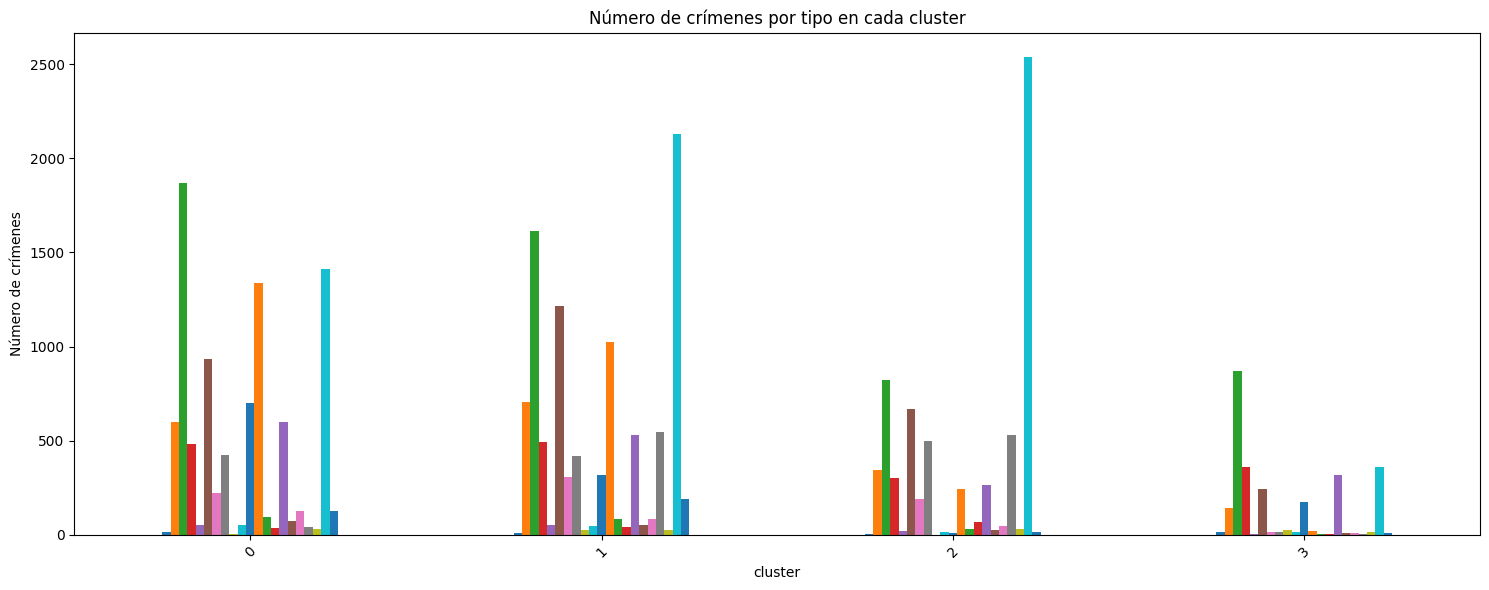

In [ ]:
results = pd.read_csv('resultados_Aglo2.csv')

crime_counts_by_cluster = results.groupby('cluster')['Primary Type'].value_counts().unstack(fill_value=0)

# Create the bar plot
crime_counts_by_cluster.plot(kind='bar', figsize=(15, 6), legend=False)
plt.title('Número de crímenes por tipo en cada cluster')
plt.xlabel('cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Convert the 'Date' column to datetime objects
results['Date'] = pd.to_datetime(results['Date'])

# Extract month and year
results['Month'] = results['Date'].dt.month
results['Year'] = results['Date'].dt.year

# Group by cluster, month, and crime type, then count occurrences
crime_frequencies = results.groupby(['Cluster', 'Month', 'Primary Type'])['ID'].count().reset_index()

# Display the result
print(crime_frequencies)


#Optional: Pivot table for better visualization
crime_frequencies_pivot = crime_frequencies.pivot_table(index=['Cluster', 'Month'], columns='Primary Type', values='ID', fill_value=0)
crime_frequencies_pivot

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 8))

# Generar el gráfico basado en la tabla pivote
crime_frequencies_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20',  # Colores variados para cada tipo de crimen
    width=0.8
)

# Configurar etiquetas y título
ax.set_title("Frecuencia de delitos por clúster y mes", fontsize=16)
ax.set_xlabel("Clúster y Mes", fontsize=14)
ax.set_ylabel("Número de delitos", fontsize=14)
ax.set_xticks(range(len(crime_frequencies_pivot.index)))
ax.set_xticklabels(
    [f"Clúster {clusterA}, Mes {month}" for clusterA, month in crime_frequencies_pivot.index],
    rotation=45,
    ha="right"
)
ax.legend(title="Tipo de crimen", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
location_counts_by_cluster = results.groupby('Cluster')['Location Description'].value_counts().unstack(fill_value=0)
print(location_counts_by_cluster)

# Create the bar plot
location_counts_by_cluster.plot(kind='bar', figsize=(15, 6), legend=False)
plt.title('Número de crímenes por ubicación en cada cluster')
plt.xlabel('Cluster')
plt.ylabel('Número de crímenes')
plt.xticks(rotation=45)
#plt.legend(title='Location Description')
plt.tight_layout()
plt.show()

In [ ]:
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_freq = results.groupby(['Cluster', 'Location Description'])['ID'].count().reset_index()
print(location_description_freq)
# Crear la tabla pivote para visualizar las frecuencias por ubicación y clúster
location_description_pivot = location_description_freq.pivot_table(index='Cluster', columns='Location Description', values='ID', aggfunc='sum', fill_value=0)

# Crear el gráfico de barras apiladas
location_description_pivot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

# Configurar etiquetas y título
plt.title("Frecuencia de delitos por ubicación de cada clúster", fontsize=16)
plt.xlabel("Clúster", fontsize=14)
plt.ylabel("Número de delitos", fontsize=14)
plt.xticks(rotation=0)
plt.legend(title="Ubicación del delito", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


In [ ]:
# Analizar patrones por hora del día
plt.figure(figsize=(12, 6))
sns.countplot(data=crimes_new1, x='Hour', hue='cluster', palette='tab10')
plt.title("Distribución de crímenes por hora del día y clúster")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de crímenes")
plt.show()

In [ ]:
from folium.plugins import HeatMap

# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Filtrar los datos excluyendo el clúster -1
filtered_data = crimes_new1[crimes_new1['cluster'] != -1]

# Preparar los datos para el mapa de calor
heat_data = filtered_data[['Latitude', 'Longitude']].dropna()

# Agregar el mapa de calor
HeatMap(data=heat_data.values, radius=15).add_to(chicago_map)

# Guardar el mapa
chicago_map.save("mapa_calor_clusters.html")
print("Mapa de calor generado: mapa_calor_clusters.html")

In [ ]:
# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Añadir puntos de los clústeres
for _, row in crimes_new1.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=f'#{hash(row["cluster"]) % 0xFFFFFF:06x}',  # Color basado en clúster
        fill=True,
        fill_opacity=0.6
    ).add_to(chicago_map)

# Mostrar el mapa
chicago_map.save("chicago_clusters_map.html")
print("Mapa guardado como chicago_clusters_map.html")


In [ ]:
import folium

# Definir colores para los clústeres
cluster_colors = {
    0: 'yellow',
    1: 'red',
    2: 'blue',
    3: 'orange'
}

# Crear un mapa centrado en Chicago
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)

# Añadir puntos de los clústeres al mapa
for _, row in crimes_new1.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=cluster_colors.get(row['cluster'], 'gray'),  # Color basado en el clúster
        fill=True,
        fill_opacity=0.6
    ).add_to(chicago_map)

# Guardar el mapa
chicago_map.save("chicago_clusters_map.html")
print("Mapa guardado como chicago_clusters_map.html")

